# UC1 — Multi-condition causal signaling with AnnNet as the hub

An end-to-end biology pipeline where **AnnNet is the central data
structure** that holds the prior-knowledge network, multi-omics state,
per-patient causal inferences, and downstream-ML hand-off — without ever
leaving a single graph object.

We start from the OmniPath signed-directed prior knowledge network
(PKN). CPTAC LUAD (lung adenocarcinoma) transcriptomics and
phosphoproteomics are layered on top, one Kivelä elementary layer per
patient. decoupler infers per-patient transcription-factor and kinase
activities. CORNETO/CARNIVAL solves a sparse signed-causal sub-network
per patient. The inferred topology is registered as a second AnnNet
*slice* alongside the prior. A consensus elementary layer aggregates
across the cohort. Inter-layer coupling edges materialize the same gene
across patient layers. A backend swap into igraph computes PageRank in
C. Provenance is captured as a snapshot diff. The graph is exported to
CX2 for Cytoscape and to a PyG `HeteroData` for GNN training.

**What AnnNet provides that nothing else does, exercised here**

- one container for PKN topology *and* per-patient state — no parallel
  dict-of-dicts (§§3–8)
- **slices** as alternative-topology overlays on the same graph — prior
  vs inferred views without rebuilding (§13)
- native **Kivelä multilayer** with inter-layer coupling edges, sliced
  per layer-tuple (§§8, 14, 20)
- **multi-backend** algorithm access (NetworkX, igraph, graph-tool, PyG)
  with the result written straight back as a vertex-layer attribute
  (§17)
- Polars-backed attribute tables for vectorized edge/vertex queries
- **provenance** snapshots + diff at every pipeline stage (§22)
- lossless export to CX2 (Cytoscape) and PyG (GNN training) from the
  same object (§§23, 25)

The notebook is framed as a software case study. External biological
validation and method-vs-method benchmarks are out of scope; we report
sanity checks (degree-bias, null-cohort) but do not claim biological
discovery.


## 1. Configuration

All major assumptions are explicit here. The defaults are conservative and publication-oriented rather than optimized for speed.


In [1]:
from pathlib import Path

SEED = 7

TOP_MUT_QUANTILES = {
    'top10': 0.90,
    'top20': 0.80,
}
PRIMARY_COHORT_LABEL = 'top10'
SENSITIVITY_COHORT_LABELS = ['top10', 'top20']
INCLUDE_ALL_MATCHED_COHORT = True

KIN_TH = 1.5
TF_TH = 1.5
TOP_K_KIN = 10
TOP_TF_POS = 8
TOP_TF_NEG = 7
ULM_TMIN_CANDIDATES = [5, 3, 1]

REGULARIZATION_GRID = [0.0, 0.01, 0.1]
PRIMARY_LAMBDA = 0.01
SOLVER_CANDIDATES = ['scip', 'highs', 'cbc', 'glpk']
ACCEPTABLE_SOLVER_STATUSES = {
    'optimal',
    'optimal_inaccurate',
    'feasible',
    'feasible_inaccurate',
}

CONSENSUS_MIN_FREQ = 0.50
CORNETO_SIG_THRESHOLD = 0.50
NULL_REPEATS = 100
TOP_N_PLOT = 50

EXPORT_PYG = True
SAVE_ANNNET = True
EXPORT_HISTORY = True

PSP_URL = 'https://omnipathdb.org/enz_sub?genesymbols=1'

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'annnet').exists():
    for parent in [REPO_ROOT, *REPO_ROOT.parents]:
        if (parent / 'annnet').exists() and (parent / 'pyproject.toml').exists():
            REPO_ROOT = parent
            break

NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
OUTPUT_DIR = NOTEBOOK_DIR / 'uc1_fixed_outputs'
CACHE_DIR = OUTPUT_DIR / 'cache'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'
for path in [OUTPUT_DIR, CACHE_DIR, TABLE_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

ANNNET_OUT = OUTPUT_DIR / 'UC1_fixed.annnet'
PYG_OUT = OUTPUT_DIR / 'UC1_fixed_heterodata.pt'
HISTORY_OUT = OUTPUT_DIR / 'UC1_fixed_history.json'

print({'repo_root': str(REPO_ROOT), 'output_dir': str(OUTPUT_DIR)})

{'repo_root': '/mnt/c/Users/pc/desktop/annnet-remote', 'output_dir': '/mnt/c/Users/pc/desktop/annnet-remote/notebooks/uc1_fixed_outputs'}


## 2. Reproducibility Setup

This section captures versions, records optional dependencies, and fixes random seeds where relevant.
If a downstream solver or optional export dependency is missing, the notebook reports that explicitly.


In [2]:
import importlib.metadata as im
import platform
import random
import sys
import time
from collections import Counter, defaultdict
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import fisher_exact, spearmanr

random.seed(SEED)
np.random.seed(SEED)

import annnet
from annnet import to_pyg
from annnet.io.omnipath import from_omnipath
from annnet.utils.plotting import to_matplotlib

import cptac
import corneto as cn
import decoupler as dc
from corneto.methods.signalling.carnival import multi_carnival


def package_version(name: str) -> str:
    try:
        return im.version(name)
    except Exception:
        return 'not-installed'


version_table = pd.DataFrame(
    {
        'package': [
            'python',
            'annnet',
            'numpy',
            'pandas',
            'polars',
            'matplotlib',
            'scipy',
            'cptac',
            'decoupler',
            'corneto',
            'anndata',
            'torch',
            'torch-geometric',
        ],
        'version': [
            platform.python_version(),
            getattr(annnet, '__version__', 'unknown'),
            package_version('numpy'),
            package_version('pandas'),
            package_version('polars'),
            package_version('matplotlib'),
            package_version('scipy'),
            package_version('cptac'),
            package_version('decoupler'),
            package_version('corneto'),
            package_version('anndata'),
            package_version('torch'),
            package_version('torch-geometric'),
        ],
    }
)
version_table.to_csv(TABLE_DIR / 'versions.csv', index=False)

runtime_manifest = {
    'python_executable': sys.executable,
    'platform': platform.platform(),
    'seed': SEED,
    'solver_candidates': SOLVER_CANDIDATES,
    'regularization_grid': REGULARIZATION_GRID,
    'retrieval_time_utc': pd.Timestamp.utcnow().isoformat(),
}

version_table

/home/l1boll/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,package,version
0,python,3.11.6
1,annnet,0.2.0
2,numpy,2.3.5
3,pandas,2.3.3
4,polars,1.35.2
5,matplotlib,3.10.8
6,scipy,1.16.3
7,cptac,1.5.14
8,decoupler,2.1.4
9,corneto,1.0.0b7


## 3. Load OmniPath PKN

We import the prior knowledge network with signed and directional metadata plus several annotation sources.
This notebook uses the loaded PKN as a reusable prior rather than claiming that OmniPath itself is a tumor-specific ground truth.


In [ ]:
G = from_omnipath(
    dataset='omnipath',
    query={'organism': 'human', 'genesymbols': True},
    source_col='source_genesymbol',
    target_col='target_genesymbol',
    edge_attr_cols=[
        'is_stimulation',
        'is_inhibition',
        'consensus_direction',
        'consensus_stimulation',
        'consensus_inhibition',
        'n_sources',
        'n_references',
        'sources',
    ],
    slice='omnipath_pkn',
    vertex_annotation_sources=[
        'HGNC',
        'CancerGeneCensus',
        'SignaLink_function',
        'SignaLink_pathway',
        'UniProt_location',
        'IntOGen',
        'kinase.com',
        'Phosphatome',
    ],
    load_vertex_annotations=True,
)

G.history.enable(True)
G.history.snapshot('after_pkn_load')

print(f'PKN loaded: |V|={G.global_count("vertices"):,} |E|={G.global_count("edges"):,}')
print(f'Active slice: {G.slices.active}')
print(f'Edge attribute columns: {list(G.edge_attributes.columns)}')

2026-06-01 19:59:40 | [INFO] Downloading data from `https://omnipathdb.org/queries/enzsub?format=json`
2026-06-01 19:59:40 | [INFO] Downloading data from `https://omnipathdb.org/queries/interactions?format=json`
2026-06-01 19:59:40 | [INFO] Downloading data from `https://omnipathdb.org/queries/complexes?format=json`
2026-06-01 19:59:40 | [INFO] Downloading data from `https://omnipathdb.org/queries/annotations?format=json`
2026-06-01 19:59:41 | [INFO] Downloading data from `https://omnipathdb.org/queries/intercell?format=json`
2026-06-01 19:59:41 | [INFO] Downloading data from `https://omnipathdb.org/about?format=text`


[timing] fetch/receive df:     4.800s
[timing] column resolution:    0.0154s
         source='source_genesymbol'  target='target_genesymbol'  directed='is_directed'
         edge_attr_cols (8): ['is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition', 'n_sources', 'n_references', 'sources']
[timing] AnnNet init:          0.236s  (pre-sized n=85217 e=85217)
[timing] to_rows setup:        0.000s  (85217 rows, streaming=True)
[timing] bulk list build:      0.553s  (85217 edges)
[timing] add_edges_bulk:       2.728s
         vertices=8791  edges=85217
[vertex annotations] loading from cache (lazy scan + pushdown): /home/l1boll/.cache/annnet/omnipath_annotations.tsv.gz
[vertex annotations] streamed + aggregated in 22.5s  rows=28876
[vertex annotations] using pre-aggregated frame: 28,876 (gene, attr) pairs
[vertex annotations] pivoted in 0.1s
[vertex annotations] loaded 7677 vertices in 0.2s
PKN loaded: |V|=8,791 |E|=85,217
Active slice: defa

## 4. PKN Diagnostics and Trusted Edge Summary

Before any patient-specific inference, we inspect the imported network. This is not a validation step for biological truth,
but it helps distinguish strongly supported prior edges from lower-confidence prior edges.


In [4]:
pkn_edges_df = G.views.edges().to_pandas()
pkn_edges_df = pkn_edges_df[pkn_edges_df['source'].notna() & pkn_edges_df['target'].notna()].copy()

trusted_edges_df = pkn_edges_df[
    (pkn_edges_df['n_sources'].fillna(0) >= 3)
    & (pkn_edges_df['consensus_direction'].fillna(False).astype(bool))
].copy()

pkn_degree = (
    pd.concat(
        [
            pkn_edges_df['source'].value_counts(),
            pkn_edges_df['target'].value_counts(),
        ],
        axis=1,
    )
    .fillna(0)
    .sum(axis=1)
    .astype(int)
    .rename('pkn_degree')
    .sort_values(ascending=False)
)

pkn_summary = pd.DataFrame(
    {
        'metric': [
            'total_edges',
            'trusted_edges',
            'trusted_fraction',
            'unique_vertices_with_degree',
        ],
        'value': [
            len(pkn_edges_df),
            len(trusted_edges_df),
            len(trusted_edges_df) / max(len(pkn_edges_df), 1),
            pkn_degree.index.nunique(),
        ],
    }
)

pkn_summary.to_csv(TABLE_DIR / 'pkn_summary.csv', index=False)
pkn_degree.rename_axis('vertex_id').reset_index().to_csv(TABLE_DIR / 'pkn_degree.csv', index=False)

pkn_summary

,metric,value
0,total_edges,85217.000000
1,trusted_edges,12923.000000
2,trusted_fraction,0.151648
3,unique_vertices_with_degree,8791.000000


## 5. Load CPTAC LUAD Data

We load transcriptomics, phosphoproteomics, and somatic mutations. The next section checks value ranges before choosing any tumor-normal transformation.


In [5]:
luad = cptac.Luad()
rna_raw = luad.get_transcriptomics('bcm').copy()
pp_raw = luad.get_phosphoproteomics('umich').copy()
soms = luad.get_somatic_mutation('harmonized').copy()

print(
    {'rna_raw_shape': rna_raw.shape, 'phospho_raw_shape': pp_raw.shape, 'somatic_rows': len(soms)}
)

{'rna_raw_shape': (213, 59286), 'phospho_raw_shape': (213, 74579), 'somatic_rows': 39029}


## 6. Tumor-normal contrasts with range diagnostics

CPTAC processed matrices may already be normalized, centered, or contain
negative values. We:

- inspect numeric ranges and missingness before transforming anything
- construct matched tumor-normal pairs explicitly
- use **paired differences** unless a positive raw scale is clearly
  justified, and record the choice in the saved tables


In [6]:
def flatten_axis(values) -> pd.Index:
    if isinstance(values, pd.MultiIndex):
        flat = []
        for item in values.to_flat_index():
            parts = [str(x) for x in item if pd.notna(x) and str(x) != 'nan']
            flat.append('_'.join(parts))
        return pd.Index(flat, dtype='object')
    return pd.Index(values.astype(str), dtype='object')


def normalize_feature_axis(values, mode: str) -> pd.Index:
    if isinstance(values, pd.MultiIndex):
        if mode == 'gene_symbol':
            return pd.Index(values.get_level_values(0).astype(str), dtype='object')
        if mode == 'flat':
            flat = []
            for item in values.to_flat_index():
                parts = [str(x) for x in item if pd.notna(x) and str(x) != 'nan']
                flat.append('_'.join(parts))
            return pd.Index(flat, dtype='object')
        raise ValueError(f'Unknown feature normalization mode: {mode}')
    return pd.Index(values.astype(str), dtype='object')


def sanitize_sample_feature_matrix(df: pd.DataFrame, *, feature_mode: str) -> pd.DataFrame:
    out = df.copy()
    out.index = flatten_axis(out.index)
    out.columns = normalize_feature_axis(out.columns, feature_mode)
    return out


def summarize_numeric_matrix(df: pd.DataFrame, label: str) -> pd.Series:
    arr = df.to_numpy(dtype=float)
    finite_mask = np.isfinite(arr)
    finite_vals = arr[finite_mask]
    return pd.Series(
        {
            'label': label,
            'n_rows': df.shape[0],
            'n_cols': df.shape[1],
            'n_values': arr.size,
            'n_finite': int(finite_mask.sum()),
            'finite_fraction': float(finite_mask.mean()),
            'min': float(np.nanmin(arr)),
            'max': float(np.nanmax(arr)),
            'mean': float(np.nanmean(arr)),
            'median': float(np.nanmedian(arr)),
            'n_negative': int((arr < 0).sum()),
            'n_zero': int((arr == 0).sum()),
            'nan_fraction': float(np.isnan(arr).mean()),
            'inf_fraction': float(np.isinf(arr).mean()),
            'finite_mean_abs': float(np.mean(np.abs(finite_vals))) if finite_vals.size else np.nan,
        }
    )


def build_matched_pairs(sample_ids: pd.Index) -> pd.DataFrame:
    normals = {s[:-2]: s for s in sample_ids if s.endswith('.N')}
    tumors = [s for s in sample_ids if not s.endswith('.N')]
    matched = [t for t in tumors if t in normals]
    pairs = pd.DataFrame(
        {
            'tumor': matched,
            'normal': [normals[t] for t in matched],
        },
        index=matched,
    )
    pairs.index.name = 'patient_id'
    return pairs


def choose_contrast_method(df: pd.DataFrame, label: str) -> tuple[str, str]:
    summary = summarize_numeric_matrix(df, label)
    strictly_positive = bool(summary['min'] > 0 and summary['n_negative'] == 0)
    if strictly_positive:
        return (
            'difference',
            f'{label}: all observed values are positive, but the processed CPTAC scale is not explicitly confirmed as raw abundance; paired difference is used conservatively.',
        )
    return (
        'difference',
        f'{label}: detected non-positive or negative values; log2 fold-change with pseudocount would be unsafe, so paired difference is used.',
    )


def compute_paired_contrast(
    df: pd.DataFrame, matched_pairs: pd.DataFrame, method: str
) -> pd.DataFrame:
    tumor = df.loc[matched_pairs['tumor']].copy()
    normal = df.loc[matched_pairs['normal']].copy()
    tumor.index = matched_pairs.index
    normal.index = matched_pairs.index
    if method == 'log2fc':
        contrast = np.log2(tumor + 1.0) - np.log2(normal + 1.0)
    elif method == 'difference':
        contrast = tumor - normal
    else:
        raise ValueError(f'Unknown contrast method: {method}')
    return contrast.T


rna_sf = sanitize_sample_feature_matrix(rna_raw, feature_mode='gene_symbol')
# Keep the column MultiIndex; the contrast collapses to `{gene}_{site}`
# keys that match the PSP enzyme-substrate format.
pp_sf = pp_raw.copy()
pp_sf.index = flatten_axis(pp_sf.index)
if isinstance(pp_sf.columns, pd.MultiIndex):
    print(
        {
            'pp_column_levels': list(pp_sf.columns.names),
            'sample_columns': pp_sf.columns[:3].tolist(),
        }
    )
else:
    print(
        {
            'pp_columns_not_multiindex': True,
            'sample_columns': pp_sf.columns[:3].tolist(),
        }
    )

matched_pairs = build_matched_pairs(rna_sf.index)
assert len(matched_pairs) > 0, 'No matched tumor-normal RNA pairs were found.'

rna_method, rna_method_reason = choose_contrast_method(rna_sf, 'transcriptomics')
pp_method, pp_method_reason = choose_contrast_method(pp_sf, 'phosphoproteomics')

rna_contrast = compute_paired_contrast(rna_sf, matched_pairs, rna_method)
rna_contrast = rna_contrast.groupby(level=0).mean()
rna_contrast.columns = rna_contrast.columns.astype(str)

pp_contrast = compute_paired_contrast(pp_sf, matched_pairs, pp_method)
if isinstance(pp_contrast.index, pd.MultiIndex):
    pp_contrast = pp_contrast.groupby(level=[0, 1]).mean()
    pp_contrast.index = pd.Index(
        [
            '_'.join([str(x) for x in idx if pd.notna(x) and str(x) != 'nan'])
            for idx in pp_contrast.index.to_flat_index()
        ]
    )
else:
    pp_contrast = pp_contrast.groupby(level=0).mean()
pp_contrast.columns = pp_contrast.columns.astype(str)

contrast_diagnostics = pd.DataFrame(
    [
        summarize_numeric_matrix(rna_sf, 'rna_raw_samples_by_features'),
        summarize_numeric_matrix(pp_sf, 'phospho_raw_samples_by_features'),
        summarize_numeric_matrix(rna_contrast, 'rna_contrast_features_by_patient'),
        summarize_numeric_matrix(pp_contrast, 'phospho_contrast_features_by_patient'),
    ]
)
contrast_diagnostics.to_csv(TABLE_DIR / 'contrast_diagnostics.csv', index=False)

contrast_method_table = pd.DataFrame(
    {
        'data_type': ['transcriptomics', 'phosphoproteomics'],
        'method': [rna_method, pp_method],
        'justification': [rna_method_reason, pp_method_reason],
    }
)
contrast_method_table.to_csv(TABLE_DIR / 'contrast_methods.csv', index=False)

assert not np.isinf(rna_contrast.to_numpy(dtype=float)).any(), (
    'Infinite values detected in RNA contrast.'
)
assert not np.isinf(pp_contrast.to_numpy(dtype=float)).any(), (
    'Infinite values detected in phosphoproteomics contrast.'
)

print(rna_method_reason)
print(pp_method_reason)
contrast_diagnostics

{'pp_column_levels': ['Name', 'Site', 'Peptide', 'Database_ID'], 'sample_columns': [('ARF5', 'S137', 'QDMPNAMPVsELTDK', 'ENSP00000000233.5'), ('M6PR', 'S267', 'GVGDDQLGEEsEERDDHLLPM', 'ENSP00000000412.3'), ('ESRRA', 'S19S22', 'AEPAsPDsPK', 'ENSP00000000442.6')]}
transcriptomics: detected non-positive or negative values; log2 fold-change with pseudocount would be unsafe, so paired difference is used.
phosphoproteomics: detected non-positive or negative values; log2 fold-change with pseudocount would be unsafe, so paired difference is used.


,label,n_rows,n_cols,n_values,n_finite,finite_fraction,min,max,mean,median,n_negative,n_zero,nan_fraction,inf_fraction,finite_mean_abs
0,rna_raw_samples_by_features,213,59286,12627918,12627918,1.000000,0.000000,22.910000,3.936233,2.600000,0,4544395,0.000000,0.0,3.936233
1,phospho_raw_samples_by_features,213,74579,15885327,5402034,0.340064,-7.522626,8.640576,-0.018713,-0.003251,2714385,52,0.659936,0.0,0.490923
2,rna_contrast_features_by_patient,59286,102,6047172,6047172,1.000000,-15.370000,16.330000,-0.005661,0.000000,2120525,1833012,0.000000,0.0,0.758337
3,phospho_contrast_features_by_patient,69186,102,7056972,2448441,0.346953,-7.588287,9.259073,0.017126,0.031855,1183027,0,0.653047,0.0,0.706737


### 6.1. Missing-data handling

Missing values are not dropped: they flow into the diagnostic tables and
are imputed with `0.0` only at the decoupler ULM step, encoding *no
observed differential signal for that feature in that patient*.


In [7]:
activity_input_diagnostics = pd.DataFrame(
    {
        'matrix': ['rna_contrast', 'phospho_contrast'],
        'nan_fraction_before_fill': [
            float(np.isnan(rna_contrast.to_numpy(dtype=float)).mean()),
            float(np.isnan(pp_contrast.to_numpy(dtype=float)).mean()),
        ],
    }
)
activity_input_diagnostics.to_csv(TABLE_DIR / 'activity_input_missingness.csv', index=False)
activity_input_diagnostics

,matrix,nan_fraction_before_fill
0,rna_contrast,0.000000
1,phospho_contrast,0.653047


## 7. TF and Kinase Activity Inference

TF activities are inferred from the RNA contrast using CollecTRI regulons. Kinase activities are inferred from phosphosite-level contrast values using OmniPath enzyme-substrate links.
This remains an inference layer, not a direct measurement layer.


In [8]:
collectri = dc.op.collectri()

collectri_targets = set(collectri['target'].astype(str))
rna_targets = set(rna_contrast.index.astype(str))
shared_tf_targets = sorted(collectri_targets & rna_targets)
print(
    {
        'collectri_targets': len(collectri_targets),
        'rna_contrast_features': len(rna_targets),
        'shared_targets_for_tf_activity': len(shared_tf_targets),
    }
)
assert shared_tf_targets, (
    'No shared gene symbols were found between rna_contrast and CollecTRI. '
    'Inspect transcriptomics feature normalization.'
)

tf_es, _ = dc.mt.ulm(rna_contrast.fillna(0.0).T, net=collectri)

psp_cache = CACHE_DIR / 'omnipath_enz_sub.tsv'
if psp_cache.exists():
    psp = pd.read_csv(psp_cache, sep='	')
else:
    psp = pd.read_csv(PSP_URL, sep='	')
    psp.to_csv(psp_cache, sep='	', index=False)

psp_kin = psp[psp['modification'].eq('phosphorylation')][
    ['enzyme_genesymbol', 'substrate_genesymbol', 'residue_type', 'residue_offset']
].copy()
psp_kin['target'] = (
    psp_kin['substrate_genesymbol'].astype(str)
    + '_'
    + psp_kin['residue_type'].astype(str)
    + psp_kin['residue_offset'].astype(str)
)
psp_net = (
    psp_kin[['enzyme_genesymbol', 'target']]
    .rename(columns={'enzyme_genesymbol': 'source'})
    .drop_duplicates()
    .assign(weight=1.0)
)

pp_targets = set(pp_contrast.index.astype(str))
psp_targets = set(psp_net['target'].astype(str))
shared_phospho_targets = sorted(pp_targets & psp_targets)
print(
    {
        'psp_targets': len(psp_targets),
        'phospho_contrast_features': len(pp_targets),
        'shared_targets_for_kinase_activity': len(shared_phospho_targets),
    }
)
assert shared_phospho_targets, (
    'No shared phosphosite identifiers were found between pp_contrast and the OmniPath enzyme-substrate network. '
    'Inspect phosphoproteomics feature normalization.'
)

psp_overlap_net = psp_net[psp_net['target'].isin(shared_phospho_targets)].copy()
source_target_counts = (
    psp_overlap_net.groupby('source')['target'].nunique().sort_values(ascending=False)
)
print(
    {
        'kinases_with_at_least_1_shared_target': int((source_target_counts >= 1).sum()),
        'kinases_with_at_least_3_shared_targets': int((source_target_counts >= 3).sum()),
        'kinases_with_at_least_5_shared_targets': int((source_target_counts >= 5).sum()),
    }
)

kin_es = None
kin_tmin_used = None
kin_ulm_error = None
for tmin in ULM_TMIN_CANDIDATES:
    try:
        kin_es, _ = dc.mt.ulm(pp_contrast.fillna(0.0).T, net=psp_net, tmin=tmin)
        kin_tmin_used = tmin
        break
    except AssertionError as exc:
        kin_ulm_error = str(exc)

assert kin_es is not None, (
    f'Kinase activity inference failed for all tested tmin values. Last error: {kin_ulm_error}'
)
print({'kinase_ulm_tmin_used': kin_tmin_used})

activity_diagnostics = pd.DataFrame(
    [
        summarize_numeric_matrix(tf_es.T, 'tf_activity_features_by_patient'),
        summarize_numeric_matrix(kin_es.T, 'kinase_activity_features_by_patient'),
    ]
)
activity_diagnostics.to_csv(TABLE_DIR / 'activity_diagnostics.csv', index=False)

activity_overlap_diagnostics = pd.DataFrame(
    [
        {
            'activity_layer': 'tf',
            'n_network_targets': len(collectri_targets),
            'n_matrix_features': len(rna_targets),
            'n_shared_targets': len(shared_tf_targets),
            'tmin_used': 5,
        },
        {
            'activity_layer': 'kinase',
            'n_network_targets': len(psp_targets),
            'n_matrix_features': len(pp_targets),
            'n_shared_targets': len(shared_phospho_targets),
            'tmin_used': kin_tmin_used,
        },
    ]
)
activity_overlap_diagnostics.to_csv(TABLE_DIR / 'activity_overlap_diagnostics.csv', index=False)

assert np.isfinite(tf_es.to_numpy(dtype=float)).all(), 'Non-finite TF activities detected.'
assert np.isfinite(kin_es.to_numpy(dtype=float)).all(), 'Non-finite kinase activities detected.'

print({'tf_activity_shape': tf_es.shape, 'kinase_activity_shape': kin_es.shape})
display(activity_diagnostics)
activity_overlap_diagnostics

{'collectri_targets': 6675, 'rna_contrast_features': 59286, 'shared_targets_for_tf_activity': 6604}
{'psp_targets': 16200, 'phospho_contrast_features': 69186, 'shared_targets_for_kinase_activity': 3958}
{'kinases_with_at_least_1_shared_target': 1064, 'kinases_with_at_least_3_shared_targets': 444, 'kinases_with_at_least_5_shared_targets': 325}
{'kinase_ulm_tmin_used': 5}
{'tf_activity_shape': (102, 772), 'kinase_activity_shape': (102, 325)}


,label,n_rows,n_cols,n_values,n_finite,finite_fraction,min,max,mean,median,n_negative,n_zero,nan_fraction,inf_fraction,finite_mean_abs
0,tf_activity_features_by_patient,772,102,78744,78744,1.0,-14.387785,16.719053,-0.059162,-0.065713,40671,0,0.0,0.0,1.400222
1,kinase_activity_features_by_patient,325,102,33150,33150,1.0,-8.299891,17.205483,-0.192067,-0.261700,19172,0,0.0,0.0,1.405289


,activity_layer,n_network_targets,n_matrix_features,n_shared_targets,tmin_used
0,tf,6675,59286,6604,5
1,kinase,16200,69186,3958,5


## 8. Build AnnNet Patient Layers and Record Provenance

We use matched tumor patients as the patient aspect. Vertex-layer attributes store RNA contrast, TF activity, and kinase activity.
History snapshots are taken after major structural milestones.


In [9]:
graph_vertices = set(map(str, G.vertices()))
matched_patients = sorted(set(rna_contrast.columns) & set(tf_es.index) & set(kin_es.index))
assert matched_patients, 'No patients are shared across contrast and activity matrices.'

G.layers.set_aspects(['patient'], {'patient': matched_patients})
G.history.snapshot('after_patient_layers_defined')

rna_vertices = [g for g in rna_contrast.index if g in graph_vertices]
tf_vertices = [tf for tf in tf_es.columns if tf in graph_vertices]
kin_vertices = [k for k in kin_es.columns if k in graph_vertices]

for patient in matched_patients:
    aa = (patient,)
    needed = set(rna_vertices)
    needed |= set(tf_vertices)
    needed |= set(kin_vertices)
    G.add_vertices(sorted(needed), layer=aa)

    for g in rna_vertices:
        value = rna_contrast.at[g, patient]
        if pd.notna(value):
            G.layers.set_vertex_layer_attrs(g, aa, rna_contrast=float(value))

    for tf in tf_vertices:
        value = tf_es.at[patient, tf]
        if pd.notna(value):
            G.layers.set_vertex_layer_attrs(tf, aa, tf_activity=float(value))

    for kin in kin_vertices:
        value = kin_es.at[patient, kin]
        if pd.notna(value):
            G.layers.set_vertex_layer_attrs(kin, aa, kinase_activity=float(value))

patient_layer_summary = pd.DataFrame(
    {
        'metric': [
            'matched_patients',
            'rna_vertices_in_graph',
            'tf_vertices_in_graph',
            'kinase_vertices_in_graph',
        ],
        'value': [len(matched_patients), len(rna_vertices), len(tf_vertices), len(kin_vertices)],
    }
)
patient_layer_summary.to_csv(TABLE_DIR / 'patient_layer_summary.csv', index=False)
G.history.snapshot('after_omics_loaded_into_layers')
patient_layer_summary

/tmp/ipykernel_130096/1185479494.py:5: UserWarning: Declared aspects ('patient',); existing flat vertices were reassigned to placeholder layer ('_',). Set explicit layer coordinates if needed.
  G.layers.set_aspects(['patient'], {'patient': matched_patients})


,metric,value
0,matched_patients,102
1,rna_vertices_in_graph,7715
2,tf_vertices_in_graph,607
3,kinase_vertices_in_graph,315


## 9. Cohort selection and sensitivity

CORNETO scales superlinearly with input/output cardinality and PKN
density. We define a demonstration cohort (top-10% mutation burden) and
a sensitivity cohort (top-20%); both are recorded and re-used in §16.


In [10]:
interesting_mutations = {
    'Missense_Mutation',
    'Nonsense_Mutation',
    'Frame_Shift_Del',
    'Frame_Shift_Ins',
}

mut_mat = (
    soms[soms['Mutation'].isin(interesting_mutations)][['Gene', 'Tumor_Sample_Barcode']]
    .drop_duplicates()
    .assign(mutated=1)
    .pivot(index='Gene', columns='Tumor_Sample_Barcode', values='mutated')
    .fillna(0)
)
mut_mat.columns = mut_mat.columns.astype(str).str.replace('_T', '', regex=False)
mut_sum = (
    mut_mat.reindex(columns=matched_patients, fill_value=0).sum(axis=0).sort_values(ascending=False)
)

cohort_definitions = {}
for label, quantile in TOP_MUT_QUANTILES.items():
    threshold = float(mut_sum.quantile(quantile))
    cohort_definitions[label] = mut_sum[mut_sum >= threshold].index.tolist()

if INCLUDE_ALL_MATCHED_COHORT:
    cohort_definitions['all_matched'] = list(mut_sum.index)

cohort_summary_rows = []
for label, members in cohort_definitions.items():
    cohort_summary_rows.append(
        {
            'cohort_label': label,
            'n_patients': len(members),
            'mean_mutation_burden': float(mut_sum.reindex(members).mean()) if members else np.nan,
            'median_mutation_burden': float(mut_sum.reindex(members).median())
            if members
            else np.nan,
            'selection_note': (
                'demonstration cohort enriched for high mutation burden'
                if label.startswith('top')
                else 'sensitivity cohort'
            ),
        }
    )

cohort_summary = pd.DataFrame(cohort_summary_rows).sort_values('n_patients')
cohort_summary.to_csv(TABLE_DIR / 'cohort_summary.csv', index=False)

analysis_patients = sorted(
    set().union(
        *(
            set(cohort_definitions[label])
            for label in SENSITIVITY_COHORT_LABELS
            if label in cohort_definitions
        )
    )
)
assert analysis_patients, 'No patients were selected for the analysis cohorts.'

cohort_summary

,cohort_label,n_patients,mean_mutation_burden,median_mutation_burden,selection_note
0,top10,11,734.000000,607.0,demonstration cohort enriched for high mutatio...
1,top20,21,604.095238,530.0,demonstration cohort enriched for high mutatio...
2,all_matched,102,203.294118,92.5,sensitivity cohort


## 10. Signed PKN restricted to the kinase → kinase∪TF subnet

The activity-inference layer yields kinase inputs and TF outputs, so we
restrict the PKN to that subspace before CARNIVAL. This is a modeling
choice for tractability — not a claim that other signaling nodes are
irrelevant.


In [11]:
kin_set = set(map(str, kin_es.columns))
tf_set = set(map(str, tf_es.columns))

pkn_filt = pkn_edges_df[
    pkn_edges_df['source'].isin(kin_set) & pkn_edges_df['target'].isin(kin_set | tf_set)
].copy()

pkn_filt['sign'] = np.where(
    pkn_filt['consensus_stimulation'].fillna(False).astype(bool),
    1,
    np.where(pkn_filt['consensus_inhibition'].fillna(False).astype(bool), -1, 0),
)
pkn_filt = pkn_filt[pkn_filt['sign'] != 0].copy()

C_filt = cn.Graph.from_tuples(pkn_filt[['source', 'sign', 'target']].apply(tuple, axis=1).tolist())

filtered_pkn_summary = pd.DataFrame(
    {
        'metric': ['filtered_edges', 'filtered_nodes'],
        'value': [len(pkn_filt), C_filt.num_vertices],
    }
)
filtered_pkn_summary.to_csv(TABLE_DIR / 'filtered_pkn_summary.csv', index=False)
filtered_pkn_summary

,metric,value
0,filtered_edges,2624
1,filtered_nodes,601


## 11. CORNETO/CARNIVAL setup

For each patient:

- **inputs** are the highest-magnitude kinase activities above `KIN_TH`
- **outputs** are positive and negative TF activities above `TF_TH`
- `multi_carnival` solves a signed-flow problem on the filtered PKN
- `lambd` controls sparsity pressure and is swept over a small grid

Solver status and empty solutions are reported explicitly. Inferred
subnetworks are model-based hypotheses.


In [12]:
@dataclass
class PatientIO:
    patient_id: str
    inputs: dict
    outputs: dict
    n_inputs: int
    n_outputs: int


def build_patient_io(patient_id: str) -> PatientIO | None:
    if patient_id not in kin_es.index or patient_id not in tf_es.index:
        return None

    kr = kin_es.loc[patient_id]
    tr = tf_es.loc[patient_id]

    kin_top = kr[kr.abs() >= KIN_TH].abs().nlargest(TOP_K_KIN).index.tolist()
    tf_pos = tr[tr >= TF_TH].nlargest(TOP_TF_POS).index.tolist()
    tf_neg = tr[tr <= -TF_TH].nsmallest(TOP_TF_NEG).index.tolist()

    inputs = {k: float(np.sign(kr[k])) for k in kin_top}
    outputs = {tf: float(tr[tf]) for tf in tf_pos + tf_neg}

    if not inputs or not outputs:
        return None

    return PatientIO(
        patient_id=patient_id,
        inputs=inputs,
        outputs=outputs,
        n_inputs=len(inputs),
        n_outputs=len(outputs),
    )


def normalize_solver_status(status) -> str:
    return str(status).strip().lower()


def is_solver_ok(status) -> bool:
    return normalize_solver_status(status) in ACCEPTABLE_SOLVER_STATUSES


def solve_multi_carnival_with_fallback(graph, patient_payload: dict, lambd: float):
    P, G_p, meta = multi_carnival(graph, patient_payload, lambd=lambd)
    last_error = None
    for solver_name in SOLVER_CANDIDATES:
        try:
            sol = P.solve(solver=solver_name)
            return P, G_p, meta, sol, solver_name, None
        except Exception as exc:
            last_error = f'{type(exc).__name__}: {exc}'
    return P, G_p, meta, None, None, last_error


def extract_active_network(P, G_p, threshold: float) -> tuple[dict, dict]:
    vvals = np.asarray(P.expr.vertex_value.value)
    evals = np.asarray(P.expr.edge_value.value)
    if vvals.ndim == 2:
        vvals = vvals[:, 0]
    if evals.ndim == 2:
        evals = evals[:, 0]

    nodes = list(G_p.V)
    edges_cn = list(G_p.E)

    node_signal = {}
    for idx, node in enumerate(nodes):
        node = str(node)
        if node.startswith('_') or not G.has_vertex(node):
            continue
        value = float(vvals[idx])
        if abs(value) >= threshold:
            node_signal[node] = value

    edge_signal = {}
    for idx, (src_fs, tgt_fs) in enumerate(edges_cn):
        value = float(evals[idx])
        if abs(value) < threshold:
            continue
        src_list = [str(x) for x in src_fs if not str(x).startswith('_')]
        tgt_list = [str(x) for x in tgt_fs if not str(x).startswith('_')]
        if not src_list or not tgt_list:
            continue
        src, tgt = src_list[0], tgt_list[0]
        if not (G.has_vertex(src) and G.has_vertex(tgt)):
            continue
        edge_signal[(src, tgt)] = value

    return node_signal, edge_signal


patient_io_map = {
    p.patient_id: p for p in [build_patient_io(pid) for pid in analysis_patients] if p is not None
}
assert patient_io_map, 'No patients had valid kinase-input and TF-output constraints for CARNIVAL.'

carnival_rows = []
active_networks_by_lambda = {}

for lambd in REGULARIZATION_GRID:
    active_networks_by_lambda[lambd] = {}
    for _idx, patient_id in enumerate(sorted(patient_io_map), 1):
        io = patient_io_map[patient_id]
        payload = {patient_id: {'input': io.inputs, 'output': io.outputs}}
        t0 = time.time()
        P, G_p, meta, sol, solver_name, error_text = solve_multi_carnival_with_fallback(
            C_filt, payload, lambd
        )
        runtime_s = time.time() - t0

        if sol is None:
            active_networks_by_lambda[lambd][patient_id] = {
                'patient_id': patient_id,
                'lambd': lambd,
                'solver': solver_name,
                'solver_status': 'solve_failed',
                'solver_ok': False,
                'objective_value': np.nan,
                'runtime_s': runtime_s,
                'node_signal': {},
                'edge_signal': {},
                'active_node_count': 0,
                'active_edge_count': 0,
                'n_inputs': io.n_inputs,
                'n_outputs': io.n_outputs,
                'error': error_text,
            }
        else:
            status = normalize_solver_status(getattr(sol, 'status', 'unknown'))
            objective_value = (
                float(getattr(sol, 'value', np.nan))
                if getattr(sol, 'value', None) is not None
                else np.nan
            )
            node_signal, edge_signal = extract_active_network(P, G_p, CORNETO_SIG_THRESHOLD)
            active_networks_by_lambda[lambd][patient_id] = {
                'patient_id': patient_id,
                'lambd': lambd,
                'solver': solver_name,
                'solver_status': status,
                'solver_ok': is_solver_ok(status),
                'objective_value': objective_value,
                'runtime_s': runtime_s,
                'node_signal': node_signal,
                'edge_signal': edge_signal,
                'active_node_count': len(node_signal),
                'active_edge_count': len(edge_signal),
                'n_inputs': io.n_inputs,
                'n_outputs': io.n_outputs,
                'error': None,
            }

        rec = active_networks_by_lambda[lambd][patient_id]
        carnival_rows.append(
            {
                'patient_id': patient_id,
                'lambd': lambd,
                'solver': rec['solver'],
                'solver_status': rec['solver_status'],
                'solver_ok': rec['solver_ok'],
                'objective_value': rec['objective_value'],
                'runtime_s': rec['runtime_s'],
                'active_node_count': rec['active_node_count'],
                'active_edge_count': rec['active_edge_count'],
                'n_inputs': rec['n_inputs'],
                'n_outputs': rec['n_outputs'],
                'error': rec['error'],
            }
        )

carnival_summary = pd.DataFrame(carnival_rows)
carnival_summary.to_csv(TABLE_DIR / 'carnival_patient_summary.csv', index=False)

lambda_summary = (
    carnival_summary.groupby('lambd', dropna=False)
    .agg(
        n_patients=('patient_id', 'nunique'),
        solver_ok_fraction=('solver_ok', 'mean'),
        mean_active_nodes=('active_node_count', 'mean'),
        mean_active_edges=('active_edge_count', 'mean'),
        median_runtime_s=('runtime_s', 'median'),
    )
    .reset_index()
)
lambda_summary.to_csv(TABLE_DIR / 'carnival_lambda_summary.csv', index=False)

assert PRIMARY_LAMBDA in active_networks_by_lambda, (
    f'PRIMARY_LAMBDA={PRIMARY_LAMBDA} missing from active_networks_by_lambda.'
)
assert (carnival_summary['solver_ok']).any(), 'No successful/feasible CARNIVAL solution was found.'

lambda_summary


,lambd,n_patients,solver_ok_fraction,mean_active_nodes,mean_active_edges,median_runtime_s
0,0.00,21,1.0,43.952381,36.190476,1.748831
1,0.01,21,1.0,20.476190,12.666667,1.028711
2,0.10,21,1.0,20.476190,12.666667,1.120919


## 12. Write per-patient inferred subnetworks back into AnnNet

We materialize only the solutions for the analysis cohort under the
primary regularization. Solver failures and empty networks are recorded
in the summary table, not silently merged into the graph.


In [13]:
primary_patient_networks = active_networks_by_lambda[PRIMARY_LAMBDA]

written_rows = []
for patient_id, result in primary_patient_networks.items():
    if not result['solver_ok']:
        written_rows.append(
            {'patient_id': patient_id, 'written': False, 'reason': result['solver_status']}
        )
        continue
    if result['active_node_count'] == 0:
        written_rows.append(
            {'patient_id': patient_id, 'written': False, 'reason': 'empty_solution'}
        )
        continue

    aa = (patient_id,)
    endpoints = set(result['node_signal'])
    for src, tgt in result['edge_signal']:
        endpoints.add(src)
        endpoints.add(tgt)

    if endpoints:
        G.add_vertices(sorted(endpoints), layer=aa)
        for node_id in sorted(endpoints):
            G.layers.set_vertex_layer_attrs(
                node_id,
                aa,
                corneto_signal=float(result['node_signal'].get(node_id, 0.0)),
            )

    edge_specs = [
        {
            'source': (src, aa),
            'target': (tgt, aa),
            'weight': float(weight),
        }
        for (src, tgt), weight in sorted(result['edge_signal'].items())
    ]
    if edge_specs:
        G.add_edges(edge_specs)

    written_rows.append(
        {
            'patient_id': patient_id,
            'written': True,
            'reason': 'ok',
            'active_nodes': result['active_node_count'],
            'active_edges': result['active_edge_count'],
        }
    )

written_summary = pd.DataFrame(written_rows)
written_summary.to_csv(TABLE_DIR / 'written_patient_networks.csv', index=False)
G.history.snapshot('after_patient_specific_causal_networks')
written_summary.head()

,patient_id,written,reason,active_nodes,active_edges
0,C3L-00080,True,ok,20,12
1,C3L-00095,True,ok,27,19
2,C3L-00144,True,ok,19,12
3,C3L-00279,True,ok,24,15
4,C3L-01924,True,ok,18,10


## 13. Slices: prior vs inferred topology on the same graph

AnnNet slices carry alternative edge sets and let us switch between them
with a single write. We register every patient-specific CARNIVAL edge
in a dedicated `carnival_inferred` slice alongside the default
`omnipath_pkn`. Toggling the active slice gives instant prior-vs-inferred
views without rebuilding.


In [14]:
CARNIVAL_SLICE = 'carnival_inferred'
if not G.slices.exists(CARNIVAL_SLICE):
    G.slices.add(CARNIVAL_SLICE)

# Map (src_supra, tgt_supra) -> eid via the multilayer src-to-edges index.
src_to_edges = G._src_to_edges
carnival_eids: list[str] = []
for patient_id, result in primary_patient_networks.items():
    if not result['solver_ok']:
        continue
    aa = (patient_id,)
    for src, tgt in result['edge_signal']:
        skey = (src, aa)
        tkey = (tgt, aa)
        for eid in src_to_edges.get(skey, ()):
            rec = G._edges.get(eid)
            if rec is not None and rec.tgt == tkey:
                carnival_eids.append(eid)
                break

G.slices.add_edges(CARNIVAL_SLICE, carnival_eids)
print(f'CARNIVAL slice "{CARNIVAL_SLICE}": {len(carnival_eids):,} edges registered')

# Demo: same graph, two slices, two answers.
n_omni = len(G.slices.edges('omnipath_pkn'))
n_carn = len(G.slices.edges(CARNIVAL_SLICE))
print(f'  omnipath_pkn      : {n_omni:>7,} edges')
print(f'  carnival_inferred : {n_carn:>7,} edges')
G.history.snapshot('after_carnival_slice')

CARNIVAL slice "carnival_inferred": 266 edges registered
  omnipath_pkn      :  85,217 edges
  carnival_inferred :     266 edges


{'label': 'after_carnival_slice',
 'version': 148,
 'vertex_ids': {'IGFL1',
  'PTGFRN',
  'CASQ2',
  'UBE2S',
  'NOTCH4',
  'BAG2',
  'RIOK2',
  'TRIM77',
  'PRNP',
  'CLIC5',
  'KLRD1',
  'PPFIA3',
  'MAZ',
  'GRPEL1',
  'TNK2',
  'ANAPC2',
  'GCG',
  'TRIM43B',
  'TSPAN1',
  'PML',
  'RETN',
  'TAPBP',
  'ENAH',
  'VLDLR',
  'MNAT1',
  'CSN1S1',
  'ATF2_JUN',
  'BANP',
  'MTCP1',
  'ADGRE5',
  'H2BK1',
  'G3BP2',
  'ATRX',
  'GLG1',
  'TFEB',
  'CDH9',
  'SCARB1',
  'DLX5',
  'FMNL2',
  'PARP1',
  'RNF141',
  'KPNA1',
  'AP2M1',
  'ITGAV_ITGB1',
  'MCHR2',
  'GATA6',
  'CDH8',
  'DEFB4B',
  'NOXA1',
  'PLAA',
  'UGT2B7',
  'RABEPK',
  'PIM1',
  'UBIAD1',
  'PIP5K1B',
  'TREML1',
  'BRDT',
  'FAAP20',
  'CSNK1D',
  'SEC62',
  'TBX3',
  'KAT5',
  'ACVR1B_ACVR2A_CFC1',
  'FLRT2',
  'RPS27A',
  'CLEC1B',
  'NSMCE1',
  'ABR',
  'CD8A_CD8B',
  'STRAP',
  'PITRM1',
  'OMA1',
  'TP53TG5',
  'IRS4',
  'SELE',
  'TRIM22',
  'IFNA14',
  'S100A4',
  'DDX24',
  'PAX8',
  'FLT3',
  'PPP3CB',
  'RB

## 14. Consensus construction

The consensus layer aggregates per-patient inferred subnetworks. We
aggregate from **per-patient active-node and active-edge dictionaries**,
so for `n` patients every count is in `[0, n]` and every frequency is in
`[0, 1]` by construction.


In [15]:
def unique_vertex_ids(values) -> list[str]:
    seen = set()
    out = []
    for value in values:
        if isinstance(value, tuple):
            value = value[0]
        value = str(value)
        if value not in seen:
            seen.add(value)
            out.append(value)
    return out


def get_patient_active_nodes(patient_result: dict) -> set[str]:
    return set(unique_vertex_ids(patient_result.get('node_signal', {}).keys()))


def get_patient_active_edges(patient_result: dict) -> set[tuple[str, str]]:
    edges = set()
    for src, tgt in patient_result.get('edge_signal', {}):
        edges.add((str(src), str(tgt)))
    return edges


def build_consensus_layer(
    patient_results: dict, min_freq: float
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    if not patient_results:
        raise ValueError('patient_results is empty')

    n_patients = len(patient_results)
    node_counter = Counter()
    edge_counter = Counter()
    node_signal_acc = defaultdict(list)
    edge_signal_acc = defaultdict(list)
    union_nodes = set()
    union_edges = set()

    for _patient_id, result in patient_results.items():
        nodes = get_patient_active_nodes(result)
        edges = get_patient_active_edges(result)
        union_nodes |= nodes
        union_edges |= edges

        for node_id in nodes:
            node_counter[node_id] += 1
            node_signal_acc[node_id].append(float(result['node_signal'][node_id]))

        for edge_key in edges:
            edge_counter[edge_key] += 1
            edge_signal_acc[edge_key].append(float(result['edge_signal'][edge_key]))

    node_rows = []
    for node_id, count in sorted(node_counter.items(), key=lambda kv: (-kv[1], kv[0])):
        freq = count / n_patients
        assert 0 <= count <= n_patients, f'Invalid node count for {node_id}: {count}'
        assert 0.0 <= freq <= 1.0, f'Invalid node frequency for {node_id}: {freq}'
        node_rows.append(
            {
                'vertex_id': node_id,
                'active_count': count,
                'patient_frequency': freq,
                'mean_signal': float(np.mean(node_signal_acc[node_id])),
                'median_signal': float(np.median(node_signal_acc[node_id])),
                'selected_for_consensus': bool(freq >= min_freq),
            }
        )

    edge_rows = []
    for (src, tgt), count in sorted(edge_counter.items(), key=lambda kv: (-kv[1], kv[0])):
        freq = count / n_patients
        assert 0 <= count <= n_patients, f'Invalid edge count for {(src, tgt)}: {count}'
        assert 0.0 <= freq <= 1.0, f'Invalid edge frequency for {(src, tgt)}: {freq}'
        edge_rows.append(
            {
                'source': src,
                'target': tgt,
                'active_count': count,
                'patient_frequency': freq,
                'mean_signal': float(np.mean(edge_signal_acc[(src, tgt)])),
                'median_signal': float(np.median(edge_signal_acc[(src, tgt)])),
                'selected_for_consensus': bool(freq >= min_freq),
            }
        )

    node_df = pd.DataFrame(node_rows)
    edge_df = pd.DataFrame(edge_rows)

    selected_nodes = node_df[node_df['selected_for_consensus']] if not node_df.empty else node_df
    selected_edges = edge_df[edge_df['selected_for_consensus']] if not edge_df.empty else edge_df

    assert selected_nodes.shape[0] <= len(union_nodes), (
        'Consensus node count exceeded union of unique active patient nodes.'
    )
    if not selected_edges.empty:
        assert (selected_edges['patient_frequency'] <= 1.0).all(), (
            'Consensus edge frequency exceeded 1.0.'
        )

    summary = {
        'n_patients': n_patients,
        'n_union_nodes': len(union_nodes),
        'n_union_edges': len(union_edges),
        'n_consensus_nodes': int(selected_nodes.shape[0]),
        'n_consensus_edges': int(selected_edges.shape[0]),
    }
    return node_df, edge_df, summary


def add_consensus_layer_to_graph(
    graph, layer_label: str, node_df: pd.DataFrame, edge_df: pd.DataFrame
):
    if layer_label not in graph.layers.elem_layers['patient']:
        graph.layers.add_elementary_layer('patient', layer_label)
    aa = (layer_label,)

    selected_nodes = node_df[node_df['selected_for_consensus']].copy()
    selected_edges = edge_df[edge_df['selected_for_consensus']].copy()

    if not selected_nodes.empty:
        graph.add_vertices(selected_nodes['vertex_id'].tolist(), layer=aa)
        for row in selected_nodes.itertuples(index=False):
            graph.layers.set_vertex_layer_attrs(
                row.vertex_id,
                aa,
                corneto_signal=float(row.mean_signal),
                patient_frequency=float(row.patient_frequency),
                active_count=int(row.active_count),
            )

    if not selected_edges.empty:
        edge_specs = [
            {
                'source': (row.source, aa),
                'target': (row.target, aa),
                'weight': float(row.mean_signal),
            }
            for row in selected_edges.itertuples(index=False)
            if row.source in set(selected_nodes['vertex_id'])
            and row.target in set(selected_nodes['vertex_id'])
        ]
        if edge_specs:
            graph.add_edges(edge_specs)

    return aa


consensus_outputs = {}
for cohort_label in SENSITIVITY_COHORT_LABELS:
    cohort_members = [
        p
        for p in cohort_definitions[cohort_label]
        if p in primary_patient_networks and primary_patient_networks[p]['solver_ok']
    ]
    cohort_patient_results = {p: primary_patient_networks[p] for p in cohort_members}
    node_df, edge_df, summary = build_consensus_layer(cohort_patient_results, CONSENSUS_MIN_FREQ)
    summary['cohort_label'] = cohort_label
    node_df.to_csv(TABLE_DIR / f'consensus_nodes_{cohort_label}.csv', index=False)
    edge_df.to_csv(TABLE_DIR / f'consensus_edges_{cohort_label}.csv', index=False)
    consensus_outputs[cohort_label] = {
        'node_df': node_df,
        'edge_df': edge_df,
        'summary': summary,
        'layer_aa': add_consensus_layer_to_graph(G, f'consensus_{cohort_label}', node_df, edge_df),
    }

consensus_summary = pd.DataFrame([x['summary'] for x in consensus_outputs.values()])
consensus_summary.to_csv(TABLE_DIR / 'consensus_summary.csv', index=False)
G.history.snapshot('after_consensus_layers')

primary_consensus_nodes = consensus_outputs[PRIMARY_COHORT_LABEL]['node_df']
primary_consensus_edges = consensus_outputs[PRIMARY_COHORT_LABEL]['edge_df']
primary_consensus_aa = consensus_outputs[PRIMARY_COHORT_LABEL]['layer_aa']

assert (
    primary_consensus_nodes['active_count'].max()
    <= consensus_outputs[PRIMARY_COHORT_LABEL]['summary']['n_patients']
)
assert primary_consensus_nodes['patient_frequency'].max() <= 1.0
if not primary_consensus_edges.empty:
    assert (
        primary_consensus_edges['active_count'].max()
        <= consensus_outputs[PRIMARY_COHORT_LABEL]['summary']['n_patients']
    )
    assert primary_consensus_edges['patient_frequency'].max() <= 1.0

primary_consensus_nodes.sort_values(
    ['patient_frequency', 'active_count', 'vertex_id'], ascending=[False, False, True]
).head(20)

# Convenience handle reused by downstream sections (inter-layer
# coupling, sanity checks, backend swap).
primary_consensus_selected = primary_consensus_nodes[
    primary_consensus_nodes['selected_for_consensus']
].copy()


## 15. Consensus diagnostics


In [16]:
print(consensus_summary)
print('\nTop consensus nodes (primary cohort):')
display(
    primary_consensus_nodes.sort_values(
        ['patient_frequency', 'active_count', 'mean_signal'], ascending=[False, False, False]
    ).head(20)
)

print('\nTop consensus edges (primary cohort):')
display(
    primary_consensus_edges.sort_values(
        ['patient_frequency', 'active_count', 'mean_signal'], ascending=[False, False, False]
    ).head(20)
)

   n_patients  n_union_nodes  n_union_edges  n_consensus_nodes  \
0          11             93             87                 10   
1          21            115            127                 11   

   n_consensus_edges cohort_label  
0                  3        top10  
1                  3        top20  

Top consensus nodes (primary cohort):


,vertex_id,active_count,patient_frequency,mean_signal,median_signal,selected_for_consensus
0,GSK3B,11,1.000000,0.636364,1.0,True
1,CDK1,10,0.909091,1.000000,1.0,True
2,CDK2,10,0.909091,1.000000,1.0,True
4,MAPK3,10,0.909091,0.600000,1.0,True
3,CEBPA,10,0.909091,-1.000000,-1.0,True
5,MAPK1,8,0.727273,-1.000000,-1.0,True
6,E2F1,7,0.636364,1.000000,1.0,True
7,MAPK14,7,0.636364,1.000000,1.0,True
8,SPI1,7,0.636364,-1.000000,-1.0,True
9,CSNK2A1,6,0.545455,1.000000,1.0,True



Top consensus edges (primary cohort):


,source,target,active_count,patient_frequency,mean_signal,median_signal,selected_for_consensus
0,CDK1,MAPK3,8,0.727273,1.0,1.0,True
1,MAPK3,CEBPA,8,0.727273,-1.0,-1.0,True
2,CDK1,E2F1,7,0.636364,1.0,1.0,True
3,CDK2,MYC,5,0.454545,1.0,1.0,False
4,GSK3B,SPI1,5,0.454545,-1.0,-1.0,False
5,MAPK1,PPARA,4,0.363636,-1.0,-1.0,False
6,MAPK1,RUNX1,4,0.363636,-1.0,-1.0,False
7,CHEK1,E2F3,3,0.272727,1.0,1.0,False
8,EGFR,IKBKE,3,0.272727,1.0,1.0,False
9,IKBKE,IRF1,3,0.272727,-1.0,-1.0,False


## 16. Inter-layer (coupling) edges across patient layers

A real Kivelä multilayer needs coupling edges between layers, not just
intra-layer edges. For every consensus gene `v` we add a coupling edge
`(v, p_i) ↔ (v, p_j)` for every pair of patient layers where `v` was
active. After this, each patient subgraph is genuinely multilayer.


In [17]:
sig_threshold = CORNETO_SIG_THRESHOLD
inter_layer_specs: list[dict] = []
for v_row in primary_consensus_selected.itertuples():
    vid = v_row.vertex_id
    activating = [
        p
        for p, rec in primary_patient_networks.items()
        if rec.get('solver_ok') and abs(rec.get('node_signal', {}).get(vid, 0.0)) >= sig_threshold
    ]
    for i in range(len(activating)):
        for j in range(i + 1, len(activating)):
            inter_layer_specs.append(
                {
                    'source': (vid, (activating[i],)),
                    'target': (vid, (activating[j],)),
                    'edge_directed': False,
                    'weight': 1.0,
                }
            )

added_eids = G._add_edges_bulk(inter_layer_specs) if inter_layer_specs else []
print(f'Added {len(added_eids):,} inter-layer coupling edges across consensus genes')

# Re-extract one patient's subgraph WITH coupling included — now multilayer
sample_patient = sorted(primary_patient_networks.keys())[0]
sg_intra = G.layers.subgraph_from_layer_tuple((sample_patient,))
sg_full = G.layers.subgraph_from_layer_tuple((sample_patient,), include_inter=True)
print(
    f'Patient {sample_patient}: intra-only |E|={sg_intra.num_edges}  +inter |E|={sg_full.num_edges}'
)
G.history.snapshot('after_interlayer_coupling')

Added 1,134 inter-layer coupling edges across consensus genes
Patient C3L-00080: intra-only |E|=12  +inter |E|=12


{'label': 'after_interlayer_coupling',
 'version': 154,
 'vertex_ids': {'IGFL1',
  'PTGFRN',
  'CASQ2',
  'UBE2S',
  'NOTCH4',
  'BAG2',
  'RIOK2',
  'TRIM77',
  'PRNP',
  'CLIC5',
  'KLRD1',
  'PPFIA3',
  'MAZ',
  'GRPEL1',
  'TNK2',
  'ANAPC2',
  'GCG',
  'TRIM43B',
  'TSPAN1',
  'PML',
  'RETN',
  'TAPBP',
  'ENAH',
  'VLDLR',
  'MNAT1',
  'CSN1S1',
  'ATF2_JUN',
  'BANP',
  'MTCP1',
  'ADGRE5',
  'H2BK1',
  'G3BP2',
  'ATRX',
  'GLG1',
  'TFEB',
  'CDH9',
  'SCARB1',
  'DLX5',
  'FMNL2',
  'PARP1',
  'RNF141',
  'KPNA1',
  'AP2M1',
  'ITGAV_ITGB1',
  'MCHR2',
  'GATA6',
  'CDH8',
  'DEFB4B',
  'NOXA1',
  'PLAA',
  'UGT2B7',
  'RABEPK',
  'PIM1',
  'UBIAD1',
  'PIP5K1B',
  'TREML1',
  'BRDT',
  'FAAP20',
  'CSNK1D',
  'SEC62',
  'TBX3',
  'KAT5',
  'ACVR1B_ACVR2A_CFC1',
  'FLRT2',
  'RPS27A',
  'CLEC1B',
  'NSMCE1',
  'ABR',
  'CD8A_CD8B',
  'STRAP',
  'PITRM1',
  'OMA1',
  'TP53TG5',
  'IRS4',
  'SELE',
  'TRIM22',
  'IFNA14',
  'S100A4',
  'DDX24',
  'PAX8',
  'FLT3',
  'PPP3CB',


## 17. Sanity checks

Consensus hubs can arise because a node is repeatedly inferred across
patients, or because the prior network gives that node many
opportunities to appear. We test the second possibility by comparing
consensus frequency to raw PKN degree on (i) the primary cohort alone
and (ii) the union of all sensitivity cohorts (more nodes, better
power), plus a random patient-set null control.

At cohort sizes typical of UC1 the per-cohort Spearman test is
power-limited; a non-significant `p` is consistent with — but does not
prove — the absence of a degree confound. The pooled and null-model
rows below carry more weight.


In [18]:
consensus_with_degree = primary_consensus_selected.merge(
    pkn_degree.rename_axis('vertex_id').reset_index(),
    on='vertex_id',
    how='left',
).fillna({'pkn_degree': 0})

if len(consensus_with_degree) >= 2:
    degree_rho, degree_p = spearmanr(
        consensus_with_degree['patient_frequency'],
        consensus_with_degree['pkn_degree'],
    )
else:
    degree_rho, degree_p = np.nan, np.nan

# Pooled across all sensitivity cohorts — deduplicates consensus nodes, takes
# the max patient_frequency per vertex. Gives a slightly larger N for Spearman.
pooled_rows = []
for cohort_label in SENSITIVITY_COHORT_LABELS:
    node_df = consensus_outputs[cohort_label]['node_df']
    sel = node_df[node_df['selected_for_consensus']]
    if not sel.empty:
        pooled_rows.append(sel[['vertex_id', 'patient_frequency']])
if pooled_rows:
    pooled = (
        pd.concat(pooled_rows, ignore_index=True)
        .groupby('vertex_id', as_index=False)['patient_frequency']
        .max()
        .merge(
            pkn_degree.rename_axis('vertex_id').reset_index(),
            on='vertex_id',
            how='left',
        )
        .fillna({'pkn_degree': 0})
    )
    if len(pooled) >= 2:
        pooled_rho, pooled_p = spearmanr(pooled['patient_frequency'], pooled['pkn_degree'])
    else:
        pooled_rho, pooled_p = np.nan, np.nan
    pooled_n = int(len(pooled))
else:
    pooled_rho, pooled_p, pooled_n = np.nan, np.nan, 0

bias_summary = pd.DataFrame(
    {
        'metric': [
            'primary_n',
            'primary_spearman_rho',
            'primary_spearman_pvalue',
            'pooled_n',
            'pooled_spearman_rho',
            'pooled_spearman_pvalue',
        ],
        'value': [
            int(len(consensus_with_degree)),
            degree_rho,
            degree_p,
            pooled_n,
            pooled_rho,
            pooled_p,
        ],
    }
)
bias_summary.to_csv(TABLE_DIR / 'degree_bias_summary.csv', index=False)
consensus_with_degree.to_csv(TABLE_DIR / 'consensus_nodes_with_degree.csv', index=False)

solved_primary_patients = [
    p
    for p in cohort_definitions[PRIMARY_COHORT_LABEL]
    if p in primary_patient_networks and primary_patient_networks[p]['solver_ok']
]
solved_pool = [p for p, rec in primary_patient_networks.items() if rec['solver_ok']]

null_rows = []
rng = np.random.default_rng(SEED)
if solved_primary_patients and len(solved_pool) >= len(solved_primary_patients):
    observed_size = int(primary_consensus_selected.shape[0])
    observed_mean_degree = (
        float(consensus_with_degree['pkn_degree'].mean())
        if not consensus_with_degree.empty
        else np.nan
    )

    for repeat in range(NULL_REPEATS):
        sampled = rng.choice(solved_pool, size=len(solved_primary_patients), replace=False)
        sample_results = {p: primary_patient_networks[p] for p in sampled}
        sample_nodes, _, sample_summary = build_consensus_layer(sample_results, CONSENSUS_MIN_FREQ)
        sample_selected = sample_nodes[sample_nodes['selected_for_consensus']].copy()
        sample_deg = sample_selected.merge(
            pkn_degree.rename_axis('vertex_id').reset_index(),
            on='vertex_id',
            how='left',
        ).fillna({'pkn_degree': 0})
        null_rows.append(
            {
                'repeat': repeat,
                'consensus_size': int(sample_selected.shape[0]),
                'mean_pkn_degree': float(sample_deg['pkn_degree'].mean())
                if not sample_deg.empty
                else np.nan,
            }
        )

    null_df = pd.DataFrame(null_rows)
    null_df.to_csv(TABLE_DIR / 'null_patient_set_summary.csv', index=False)

    null_summary = pd.DataFrame(
        {
            'metric': [
                'observed_consensus_size',
                'null_mean_consensus_size',
                'observed_mean_degree',
                'null_mean_degree',
            ],
            'value': [
                observed_size,
                float(null_df['consensus_size'].mean()),
                observed_mean_degree,
                float(null_df['mean_pkn_degree'].mean()),
            ],
        }
    )
else:
    null_df = pd.DataFrame()
    null_summary = pd.DataFrame(
        {
            'metric': ['null_model_note'],
            'value': ['insufficient solved patients for random patient-set null model'],
        }
    )

null_summary.to_csv(TABLE_DIR / 'null_summary.csv', index=False)

print('Degree-bias check (primary vs pooled cohorts):')
display(bias_summary)
print('\nRandom patient-set null model:')
null_summary

Degree-bias check (primary vs pooled cohorts):


,metric,value
0,primary_n,10.000000
1,primary_spearman_rho,0.424467
2,primary_spearman_pvalue,0.221463
3,pooled_n,12.000000
4,pooled_spearman_rho,0.426824
5,pooled_spearman_pvalue,0.166424



Random patient-set null model:


,metric,value
0,observed_consensus_size,10.000000
1,null_mean_consensus_size,10.810000
2,observed_mean_degree,344.800000
3,null_mean_degree,314.103517


### 17.1. Optional annotation-based pathway screen

When the imported vertex annotations include a pathway-like column we
compute a Fisher's-exact over-representation screen. Reported as a
lightweight sanity check — not a formal pathway-discovery pipeline.


In [19]:
vertex_attr_df = G.vertex_attributes.to_pandas()
pathway_cols = [col for col in vertex_attr_df.columns if 'pathway' in col.lower()]
annotation_enrichment = pd.DataFrame()


def split_annotation_terms(value) -> list[str]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    text = str(value)
    for sep in ['|', ';', ',']:
        text = text.replace(sep, ';')
    return [
        term.strip() for term in text.split(';') if term.strip() and term.strip().lower() != 'nan'
    ]


if pathway_cols and not primary_consensus_selected.empty:
    col = pathway_cols[0]
    background = vertex_attr_df[['vertex_id', col]].dropna().copy()
    selected_ids = set(primary_consensus_selected['vertex_id'])

    term_to_background = Counter()
    term_to_selected = Counter()
    background_ids_with_term = defaultdict(set)
    selected_ids_with_term = defaultdict(set)

    # itertuples(name=None) -> plain tuples, so column names with ':'
    # don't get mangled by namedtuple attribute mapping.
    for vid, raw_val in background.itertuples(index=False, name=None):
        vid = str(vid)
        terms = split_annotation_terms(raw_val)
        for term in set(terms):
            background_ids_with_term[term].add(vid)
            term_to_background[term] += 1
            if vid in selected_ids:
                selected_ids_with_term[term].add(vid)
                term_to_selected[term] += 1

    rows = []
    universe = set(background['vertex_id'].astype(str))
    selected_universe = universe & selected_ids
    for term, bg_count in term_to_background.items():
        sel_count = len(selected_ids_with_term[term])
        if sel_count == 0:
            continue
        a = sel_count
        b = len(selected_universe) - a
        c = len(background_ids_with_term[term] - selected_universe)
        d = len(universe - selected_universe) - c
        _, pvalue = fisher_exact([[a, b], [c, d]], alternative='greater')
        rows.append(
            {
                'annotation_column': col,
                'term': term,
                'selected_count': a,
                'background_count': bg_count,
                'pvalue': pvalue,
            }
        )

    annotation_enrichment = pd.DataFrame(rows).sort_values(['pvalue', 'selected_count']).head(20)
    annotation_enrichment.to_csv(TABLE_DIR / 'annotation_pathway_screen.csv', index=False)
else:
    annotation_enrichment = pd.DataFrame(
        {
            'note': [
                'No pathway-like vertex annotation column was available for a lightweight screen.'
            ]
        }
    )

annotation_enrichment.head(20)

,annotation_column,term,selected_count,background_count,pvalue
3,SignaLink_pathway:pathway,T-cell receptor,4,122,0.001936
7,SignaLink_pathway:pathway,TGF,4,123,0.001999
6,SignaLink_pathway:pathway,Nuclear hormone receptor,2,61,0.045494
4,SignaLink_pathway:pathway,WNT,2,105,0.121480
0,SignaLink_pathway:pathway,Receptor tyrosine kinase,4,378,0.133214
8,SignaLink_pathway:pathway,Toll-like receptor,1,25,0.141320
2,SignaLink_pathway:pathway,Innate immune pathways,1,36,0.198200
5,SignaLink_pathway:pathway,Hedgehog,1,41,0.223037
1,SignaLink_pathway:pathway,JAK/STAT,2,152,0.226073


## 18. Cohort sensitivity

Comparison of consensus summaries between the top-10% and top-20%
mutation-burden cohorts.


In [20]:
cohort_sensitivity = []
for cohort_label, payload in consensus_outputs.items():
    node_df = payload['node_df']
    selected = node_df[node_df['selected_for_consensus']].copy()
    cohort_sensitivity.append(
        {
            'cohort_label': cohort_label,
            'n_patients': payload['summary']['n_patients'],
            'n_consensus_nodes': payload['summary']['n_consensus_nodes'],
            'median_node_frequency': float(selected['patient_frequency'].median())
            if not selected.empty
            else np.nan,
            'mean_abs_signal': float(selected['mean_signal'].abs().mean())
            if not selected.empty
            else np.nan,
        }
    )

cohort_sensitivity_df = pd.DataFrame(cohort_sensitivity)
cohort_sensitivity_df.to_csv(TABLE_DIR / 'cohort_sensitivity.csv', index=False)
cohort_sensitivity_df

,cohort_label,n_patients,n_consensus_nodes,median_node_frequency,mean_abs_signal
0,top10,11,10,0.818182,0.923636
1,top20,21,11,0.761905,0.823180


## 19. Multilayer slicing and consensus visualization

`G.layers.subgraph_from_layer_tuple` returns a real AnnNet subgraph for
any (aspect, layer) coordinate. Here we slice out the consensus layer
and render the top-N nodes.


{'consensus_layer': 'consensus_top10', 'vertices': 10, 'edges': 3}


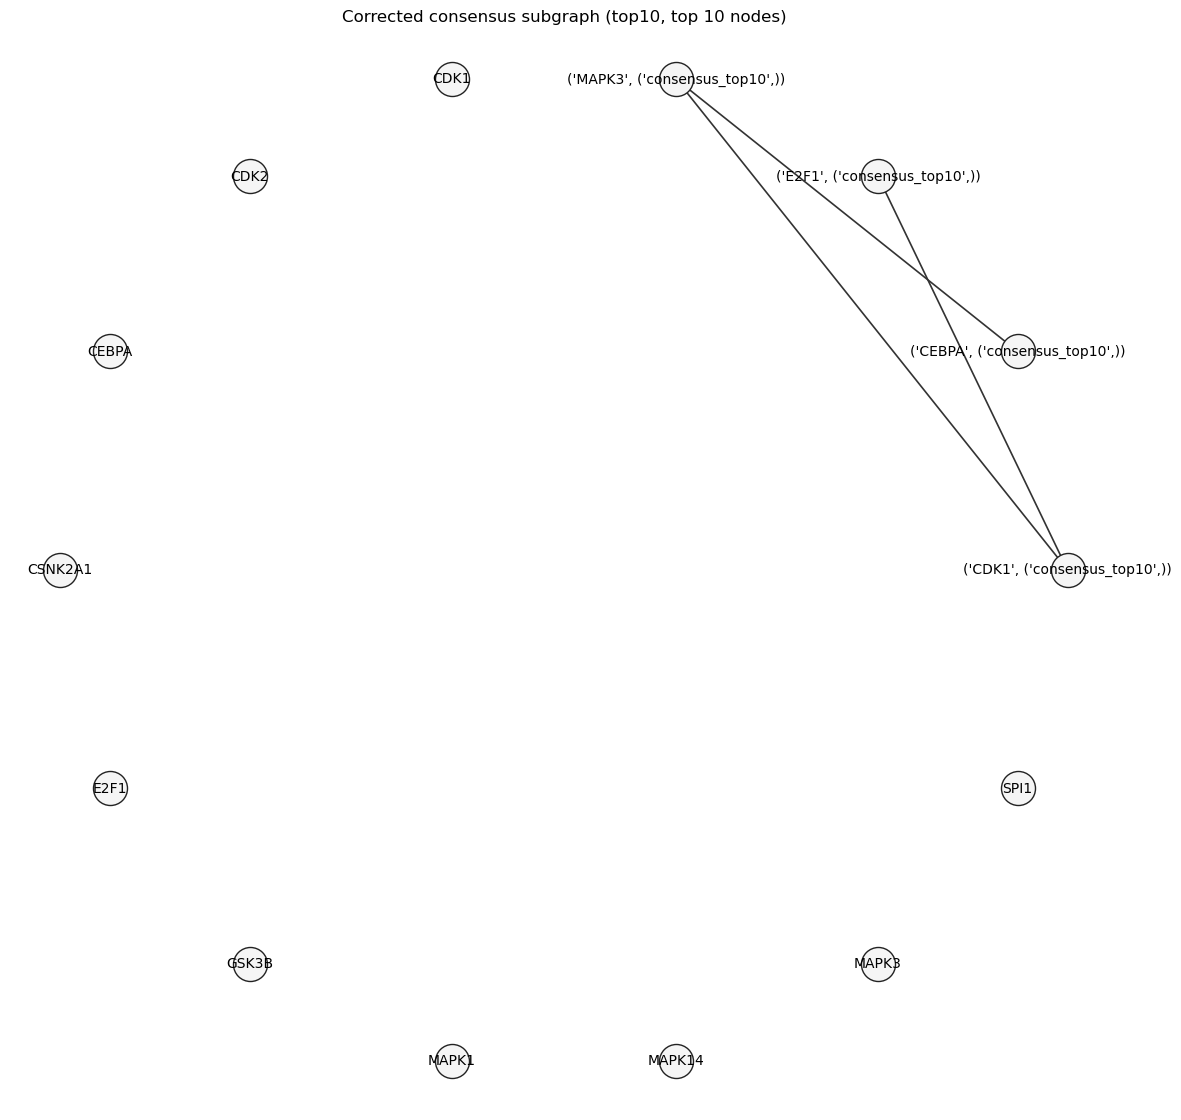

In [21]:
primary_layer_label = f'consensus_{PRIMARY_COHORT_LABEL}'
G_consensus = G.layers.subgraph_from_layer_tuple((primary_layer_label,))
print(
    {
        'consensus_layer': primary_layer_label,
        'vertices': G_consensus.global_count('vertices'),
        'edges': G_consensus.global_count('edges'),
    }
)

selected_nodes = primary_consensus_selected.sort_values(
    ['patient_frequency', 'active_count'], ascending=[False, False]
)
plot_nodes = selected_nodes['vertex_id'].head(TOP_N_PLOT).tolist()
# Extract from G_consensus (a flat single-layer subgraph) — keeps the
# extracted plot subgraph free of multilayer placeholder coordinates.
G_plot = G_consensus.ops.extract_subgraph(vertices=set(plot_nodes))

fig, ax = plt.subplots(figsize=(12, 12))
try:
    to_matplotlib(
        G_plot,
        ax=ax,
        show_vertex_labels=True,
        node_size=600,
    )
    ax.set_title(
        f'Corrected consensus subgraph ({PRIMARY_COHORT_LABEL}, top {len(plot_nodes)} nodes)'
    )
    plt.tight_layout()
    fig.savefig(
        FIG_DIR / f'consensus_plot_{PRIMARY_COHORT_LABEL}.png', dpi=200, bbox_inches='tight'
    )
    plt.show()
except Exception as exc:
    plt.close(fig)
    print(f'Plot backend issue: {type(exc).__name__}: {exc}')

## 20. Backend swap — igraph PageRank, written back as a layer attribute

The `G.ig`, `G.gt`, `G.nx` accessors materialize the graph as the
foreign library's native object on demand, cached across calls. For
algorithms with a fast C implementation, this is the path to take.
Results land back in AnnNet as vertex-layer attributes via
`set_vertex_layer_attrs`.


In [22]:
import time as _time

t0 = _time.perf_counter()
ig_sub = G_consensus.ig.backend()
t_export = _time.perf_counter() - t0

t0 = _time.perf_counter()
pageranks = ig_sub.pagerank()
t_pr = _time.perf_counter() - t0


def _bare(n):
    """Unwrap (vid, layer_coord) supra-node names back to bare vid."""
    if isinstance(n, tuple) and len(n) == 2 and isinstance(n[1], tuple):
        return n[0]
    return n


names = ig_sub.vs['name']
pr_map = {_bare(names[i]): float(pageranks[i]) for i in range(len(names))}

consensus_aa = (f'consensus_{PRIMARY_COHORT_LABEL}',)
for vid, p in pr_map.items():
    G.layers.set_vertex_layer_attrs(vid, consensus_aa, pagerank=p)

print(f'igraph backend export: {t_export * 1000:6.1f} ms')
print(f'igraph pagerank      : {t_pr * 1000:6.1f} ms')
print('Top consensus nodes by PageRank:')
for vid, p in sorted(pr_map.items(), key=lambda kv: -kv[1])[:8]:
    print(f'  {vid:>10}  {p:.4f}')
G.history.snapshot('after_backend_swap')

igraph backend export:   65.9 ms
igraph pagerank      :    1.3 ms
Top consensus nodes by PageRank:
       CEBPA  0.1377
       MAPK3  0.0887
        E2F1  0.0887
       GSK3B  0.0623
       MAPK1  0.0623
        CDK1  0.0623
        CDK2  0.0623
        SPI1  0.0623


/mnt/c/Users/pc/desktop/annnet-remote/annnet/core/backend_accessors/_base.py:156: RuntimeWarning: AnnNet-igraph conversion is lossy: multiple slices flattened into single igraph graph.
  entry = dict(build())


{'label': 'after_backend_swap',
 'version': 155,
 'vertex_ids': {'IGFL1',
  'PTGFRN',
  'CASQ2',
  'UBE2S',
  'NOTCH4',
  'BAG2',
  'RIOK2',
  'TRIM77',
  'PRNP',
  'CLIC5',
  'KLRD1',
  'PPFIA3',
  'MAZ',
  'GRPEL1',
  'TNK2',
  'ANAPC2',
  'GCG',
  'TRIM43B',
  'TSPAN1',
  'PML',
  'RETN',
  'TAPBP',
  'ENAH',
  'VLDLR',
  'MNAT1',
  'CSN1S1',
  'ATF2_JUN',
  'BANP',
  'MTCP1',
  'ADGRE5',
  'H2BK1',
  'G3BP2',
  'ATRX',
  'GLG1',
  'TFEB',
  'CDH9',
  'SCARB1',
  'DLX5',
  'FMNL2',
  'PARP1',
  'RNF141',
  'KPNA1',
  'AP2M1',
  'ITGAV_ITGB1',
  'MCHR2',
  'GATA6',
  'CDH8',
  'DEFB4B',
  'NOXA1',
  'PLAA',
  'UGT2B7',
  'RABEPK',
  'PIM1',
  'UBIAD1',
  'PIP5K1B',
  'TREML1',
  'BRDT',
  'FAAP20',
  'CSNK1D',
  'SEC62',
  'TBX3',
  'KAT5',
  'ACVR1B_ACVR2A_CFC1',
  'FLRT2',
  'RPS27A',
  'CLEC1B',
  'NSMCE1',
  'ABR',
  'CD8A_CD8B',
  'STRAP',
  'PITRM1',
  'OMA1',
  'TP53TG5',
  'IRS4',
  'SELE',
  'TRIM22',
  'IFNA14',
  'S100A4',
  'DDX24',
  'PAX8',
  'FLT3',
  'PPP3CB',
  'RBM1

## 21. PyG `HeteroData` export

Lossless export of vertex-by-edge incidence + attributes into PyG's
heterogeneous format, ready for GNN training in §25.


In [23]:
export_rows = []

if EXPORT_PYG:
    try:
        pyg_data = to_pyg(G, hyperedge_mode='skip')
        try:
            import torch

            torch.save(pyg_data, PYG_OUT)
            export_rows.append(
                {
                    'export': 'PyG HeteroData',
                    'ok': True,
                    'path': str(PYG_OUT),
                    'details': f'node_types={list(pyg_data.node_types)}, edge_types={list(pyg_data.edge_types)}',
                }
            )
        except Exception as exc:
            export_rows.append(
                {
                    'export': 'PyG HeteroData',
                    'ok': False,
                    'path': str(PYG_OUT),
                    'details': f'torch save failed: {type(exc).__name__}: {exc}',
                }
            )
    except Exception as exc:
        export_rows.append(
            {
                'export': 'PyG HeteroData',
                'ok': False,
                'path': str(PYG_OUT),
                'details': f'{type(exc).__name__}: {exc}',
            }
        )

export_summary = pd.DataFrame(export_rows)
export_summary.to_csv(TABLE_DIR / 'export_summary.csv', index=False)
export_summary

,export,ok,path,details
0,PyG HeteroData,True,/mnt/c/Users/pc/desktop/annnet-remote/notebook...,"node_types=['default'], edge_types=[('default'..."


## 22. Provenance — snapshot diff across pipeline stages

`G.history.snapshot(label)` records the structural state at each stage.
`G.history.diff(a, b)` returns the set differences between two
snapshots. The table below summarizes the per-stage delta — manuscript
artifact, auditable, machine-readable.


In [24]:
diff_rows = []
all_snapshots = list(G.history.list_snapshots())
labels = [s['label'] for s in all_snapshots]
for i in range(1, len(labels)):
    d = G.history.diff(labels[i - 1], labels[i])
    diff_rows.append(
        {
            'from': labels[i - 1],
            'to': labels[i],
            'vertices_added': len(d.vertices_added),
            'vertices_removed': len(d.vertices_removed),
            'edges_added': len(d.edges_added),
            'edges_removed': len(d.edges_removed),
            'slices_added': len(d.slices_added),
            'slices_removed': len(d.slices_removed),
        }
    )

diff_df = pd.DataFrame(diff_rows)
diff_df.to_csv(TABLE_DIR / 'history_diff_table.csv', index=False)

snapshots = pd.DataFrame(all_snapshots)[['label', 'version']]
snapshots.to_csv(TABLE_DIR / 'history_snapshots.csv', index=False)

if EXPORT_HISTORY:
    try:
        G.history.export(str(HISTORY_OUT))
    except Exception as exc:
        print(f'History export failed: {type(exc).__name__}: {exc}')

print('Snapshots:')
display(snapshots)
print('\nStructural changes per pipeline stage:')
display(diff_df)

Snapshots:


,label,version
0,after_pkn_load,0
1,after_patient_layers_defined,1
2,after_omics_loaded_into_layers,104
3,after_patient_specific_causal_networks,147
4,after_carnival_slice,148
5,after_consensus_layers,153
6,after_interlayer_coupling,154
7,after_backend_swap,155



Structural changes per pipeline stage:


,from,to,vertices_added,vertices_removed,edges_added,edges_removed,slices_added,slices_removed
0,after_pkn_load,after_patient_layers_defined,0,0,0,0,0,0
1,after_patient_layers_defined,after_omics_loaded_into_layers,0,0,0,0,0,0
2,after_omics_loaded_into_layers,after_patient_specific_causal_networks,0,0,266,0,0,0
3,after_patient_specific_causal_networks,after_carnival_slice,0,0,0,0,1,0
4,after_carnival_slice,after_consensus_layers,0,0,6,0,0,0
5,after_consensus_layers,after_interlayer_coupling,0,0,1134,0,0,0
6,after_interlayer_coupling,after_backend_swap,0,0,0,0,0,0


## 23. CX2 export for Cytoscape

One call. The output `.cx2` opens directly in Cytoscape (File → Import →
Network from File) for interactive review of the consensus subnetwork.


In [25]:
from annnet.io.cx2 import to_cx2

cx2_path = FIG_DIR / f'consensus_{PRIMARY_COHORT_LABEL}.cx2'
to_cx2(G_consensus, str(cx2_path))
print(f'Wrote {cx2_path}')

Wrote /mnt/c/Users/pc/desktop/annnet-remote/notebooks/uc1_fixed_outputs/figures/consensus_top10.cx2


## 24. Save the AnnNet snapshot

The `.annnet` archive is the canonical artifact; CSV tables under
`tables/` make the per-stage numerics auditable without reopening the
graph.


In [26]:
if SAVE_ANNNET:
    G.write(ANNNET_OUT, overwrite=True)
    print(f'Wrote {ANNNET_OUT}')
else:
    print('SAVE_ANNNET=False, skipping graph export.')

Wrote /mnt/c/Users/pc/desktop/annnet-remote/notebooks/uc1_fixed_outputs/UC1_fixed.annnet


## 25. Closing the loop — GNN training on the PyG export

Load the PyG export from §21 and train a 2-layer GraphSAGE on a binary
node-classification task: predict CancerGeneCensus membership from PKN
topology. We compare ROC-AUC against a degree-only logistic baseline
to confirm the export carries structural signal beyond degree.


In [27]:
import torch
import torch.nn.functional as _F
from torch_geometric.nn import SAGEConv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

pyg_data = torch.load(PYG_OUT, weights_only=False)
node_type = next(iter(pyg_data.node_types))
edge_type = next(iter(pyg_data.edge_types))
n = pyg_data[node_type].num_nodes
ei = pyg_data[edge_type].edge_index
print(f'PyG: {n:,} nodes  {ei.shape[1]:,} edges  ({node_type=}, {edge_type=})')

vattr_df = G.vertex_attributes.to_pandas()
ccg_cols = [c for c in vattr_df.columns if 'CancerGeneCensus' in c]

if not ccg_cols:
    print('No CancerGeneCensus annotation column — GNN demo skipped.')
else:
    col = ccg_cols[0]
    pos_vids = set(vattr_df.loc[vattr_df[col].notna(), 'vertex_id'])
    node_idx_map = pyg_data.manifest['node_index'][node_type]
    # node_idx_map is dict[vid -> idx]; produce a vid-ordered label tensor
    idx_to_vid = {idx: vid for vid, idx in node_idx_map.items()}
    y = torch.tensor(
        [1.0 if idx_to_vid[i] in pos_vids else 0.0 for i in range(n)], dtype=torch.float
    )
    n_pos = int(y.sum())
    print(f'Labels: {n_pos:,} CancerGeneCensus positive / {n:,} ({n_pos / n:.1%})')

    # Features: log(1+degree) as a single scalar
    deg = torch.zeros(n)
    deg.index_add_(0, ei[0], torch.ones(ei.shape[1]))
    deg.index_add_(0, ei[1], torch.ones(ei.shape[1]))
    x = torch.log1p(deg).unsqueeze(-1)

    torch.manual_seed(SEED)
    perm = torch.randperm(n)
    tr, va = perm[: int(0.7 * n)], perm[int(0.7 * n) :]

    class _SAGE(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.c1 = SAGEConv(1, 16)
            self.c2 = SAGEConv(16, 1)

        def forward(self, x, ei):
            return self.c2(_F.relu(self.c1(x, ei)), ei)

    model = _SAGE()
    opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
    for _epoch in range(100):
        model.train()
        opt.zero_grad()
        out = model(x, ei).squeeze(-1)
        loss = _F.binary_cross_entropy_with_logits(out[tr], y[tr])
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        scores = torch.sigmoid(model(x, ei).squeeze(-1))
    auc_gnn = roc_auc_score(y[va].numpy(), scores[va].numpy())

    # Degree-only logistic baseline
    lr_clf = LogisticRegression(max_iter=1000).fit(x[tr].numpy(), y[tr].numpy())
    auc_deg = roc_auc_score(y[va].numpy(), lr_clf.predict_proba(x[va].numpy())[:, 1])

    print(f'GraphSAGE  val ROC-AUC: {auc_gnn:.3f}')
    print(f'Degree-only baseline  : {auc_deg:.3f}')
    print(f'Lift over degree      : {auc_gnn - auc_deg:+.3f}')


PyG: 8,791 nodes  85,217 edges  (node_type='default', edge_type=('default', 'edge', 'default'))
Labels: 628 CancerGeneCensus positive / 8,791 (7.1%)
GraphSAGE  val ROC-AUC: 0.765
Degree-only baseline  : 0.701
Lift over degree      : +0.064


## 26. Notes and scope

This notebook is positioned as an AnnNet software case study. It shows
how a single AnnNet object organises priors, omics-derived activities,
patient-specific causal subnetworks, multilayer state, provenance, and
export surfaces. It does not claim biological discovery; external
validation and method-vs-method benchmarks are out of scope.
